In [11]:
'''
参考 Task 0 https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html
 name → language 考虑到了语义 hidden_state ous adj. ly adv.  Tom+hidden_state → output
参考 Task 1 https://pytorch.org/tutorials/intermediate/char_rnn_generation_tutorial.html 
 language → name  需要去学习这个语言的特点 （理论）
 （具体实现方法）
 'Chaim'作为输入 同时又作为输入
C h 语义变化的
h a
a i
i m
m <EOS>
任务过程： Russian Juily random生成
结果展示： Russian RUS R开头的name U开头的name S开头的name
'''

"\n参考 Task 0 https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html\n name → language 考虑到了语义 hidden_state ous adj. ly adv.  Tom+hidden_state → output\n参考 Task 1 https://pytorch.org/tutorials/intermediate/char_rnn_generation_tutorial.html \n language → name  需要去学习这个语言的特点 （理论）\n （具体实现方法）\n 'Chaim'作为输入 同时又作为输入\nC h 语义变化的\nh a\na i\ni m\nm <EOS>\n任务过程： Russian Juily random生成\n结果展示： Russian RUS R开头的name U开头的name S开头的name\n"

In [12]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob # path 读取指定路径下的特有格式的文件
import os
import unicodedata 
import string
all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 1 # Plus EOS marker
# 统一 成 英文
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )
print(unicodeToAscii("O'Néàl"))
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')# strip 去掉前后空格
    return [unicodeToAscii(line) for line in lines]#语法糖
# → index 
category_lines = {}
all_categories = []
def findFiles(path): return glob.glob(path)
for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)
print('# categories:', n_categories, all_categories)

O'Neal
# categories: 18 ['Czech', 'German', 'Arabic', 'Japanese', 'Chinese', 'Vietnamese', 'Russian', 'French', 'Irish', 'English', 'Spanish', 'Greek', 'Italian', 'Portuguese', 'Scottish', 'Dutch', 'Korean', 'Polish']


In [13]:
import torch
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        # i2h input → hidden语义 语言+单词+语义 
        # i2o input → output输出 output_size = input_size
        # o2o output  单词+语义 单词     
        self.i2h = nn.Linear(n_categories + input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(n_categories + input_size + hidden_size, output_size)
        self.o2o = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1) #过拟合
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, category, input, hidden):
        input_combined = torch.cat((category, input, hidden), 1)
        hidden = self.i2h(input_combined)
        output = self.i2o(input_combined)
        output_combined = torch.cat((hidden, output), 1)
        output = self.o2o(output_combined)
        output = self.dropout(output)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

In [14]:
import random

# 列表中的随机项
def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]# eg 0-10 7

# 从该类别中获取随机类别和随机行
def randomTrainingPair():
    #语言
    category = randomChoice(all_categories)
    # 语言下的单词
    line = randomChoice(category_lines[category])
    return category, line

In [15]:
# 类别的One-hot张量
def categoryTensor(category):
    li = all_categories.index(category)
    tensor = torch.zeros(1, n_categories)
    tensor[0][li] = 1
    return tensor

# 用于输入的从头到尾字母（不包括EOS）的one-hot矩阵
def inputTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)# 1 batch 一个个输进去所以默认batch为1
    for li in range(len(line)):
        letter = line[li]
        tensor[li][0][all_letters.find(letter)] = 1
    return tensor

# 用于目标的第二个结束字母（EOS）的LongTensor
def targetTensor(line):
    letter_indexes = [all_letters.find(line[li]) for li in range(1, len(line))]
    letter_indexes.append(n_letters - 1) # EOS
    return torch.LongTensor(letter_indexes)
# Alt A l  l t  t <EOS>

In [16]:
# 从随机(类别，行)对中创建类别，输入和目标张量
def randomTrainingExample():
    category, line = randomTrainingPair()
    category_tensor = categoryTensor(category)
    input_line_tensor = inputTensor(line)
    target_line_tensor = targetTensor(line)
    return category_tensor, input_line_tensor, target_line_tensor

In [17]:
criterion = nn.NLLLoss()

learning_rate = 0.0005

def train(category_tensor, input_line_tensor, target_line_tensor):
    target_line_tensor.unsqueeze_(-1)
    hidden = rnn.initHidden()

    rnn.zero_grad()

    loss = 0

    for i in range(input_line_tensor.size(0)):
        output, hidden = rnn(category_tensor, input_line_tensor[i], hidden)
        l = criterion(output, target_line_tensor[i])
        loss += l

    loss.backward()

    for p in rnn.parameters():
        p.data.add_(-learning_rate, p.grad.data)

    return output, loss.item() / input_line_tensor.size(0)

In [18]:
import time
import math

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

In [20]:
rnn = RNN(n_letters, 128, n_letters)

n_iters = 10000
print_every = 500
plot_every = 200
all_losses = []
total_loss = 0 # Reset every plot_every iters

start = time.time()

for iter in range(1, n_iters + 1):
    output, loss = train(*randomTrainingExample())
    total_loss += loss

    if iter % print_every == 0:
        print('%s (%d %d%%) %.4f' % (timeSince(start), iter, iter / n_iters * 100, loss))

    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0

0m 2s (500 5%) 3.7416
0m 4s (1000 10%) 3.3444
0m 6s (1500 15%) 4.0735
0m 8s (2000 20%) 3.0607
0m 10s (2500 25%) 2.7794
0m 12s (3000 30%) 3.0861
0m 14s (3500 35%) 3.0647
0m 17s (4000 40%) 3.4929
0m 19s (4500 45%) 2.5769
0m 21s (5000 50%) 3.3249
0m 23s (5500 55%) 3.1135
0m 26s (6000 60%) 3.1373
0m 28s (6500 65%) 2.8444
0m 30s (7000 70%) 2.4312
0m 32s (7500 75%) 2.5483
0m 34s (8000 80%) 2.8935
0m 36s (8500 85%) 2.3949
0m 39s (9000 90%) 2.8917
0m 41s (9500 95%) 2.9405
0m 43s (10000 100%) 3.1625


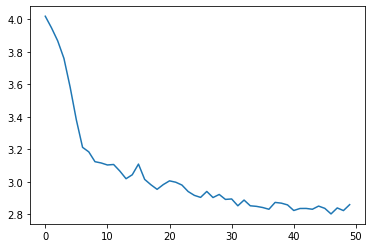

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
plt.figure()
plt.plot(all_losses)

In [22]:
[[4]][0]

[4]

In [70]:
a = torch.randn(1,3)
a
a.topk(1)

tensor([[ 0.3404, -0.2321,  1.1735]])

(tensor([[1.1735]]), tensor([[2]]))

In [ ]:
'Toy'

In [71]:
max_length = 20

# 来自类别和首字母的样本
def sample(category, start_letter='A'):
    with torch.no_grad():  # no need to track history in sampling
        category_tensor = categoryTensor(category)
        input = inputTensor(start_letter)
        hidden = rnn.initHidden()

        output_name = start_letter

        for i in range(max_length):
            output, hidden = rnn(category_tensor, input[0], hidden)
            topv, topi = output.topk(1)
            topi = topi[0][0]
            if topi == n_letters - 1:#<EOS>
                break
            else:
                letter = all_letters[topi]
                output_name += letter
            input = inputTensor(letter)

        return output_name

# 从一个类别和多个起始字母中获取多个样本
def samples(category, start_letters='ABC'):
    for start_letter in start_letters:
        print(sample(category, start_letter))

samples('Russian', 'RUS')

samples('German', 'GER')

samples('Spanish', 'SPA')

samples('Chinese', 'CHI')

Raneee
Uanie
Sanee
Gana
Eone
Ronee
Sara
Pane
Aoan
Can
Han
Ian
